In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df_train = pd.read_csv('/kaggle/LoanApprovalPredictions/train.csv')
df_test = pd.read_csv('/kaggle/LoanApprovalPredictions/test.csv')
df_sub = pd.read_csv('/kaggle/LoanApprovalPredictions/sample_submission.csv')

In [ ]:
df_train.head()

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0


In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          58645 non-null  int64  
 1   person_age                  58645 non-null  int64  
 2   person_income               58645 non-null  int64  
 3   person_home_ownership       58645 non-null  object 
 4   person_emp_length           58645 non-null  float64
 5   loan_intent                 58645 non-null  object 
 6   loan_grade                  58645 non-null  object 
 7   loan_amnt                   58645 non-null  int64  
 8   loan_int_rate               58645 non-null  float64
 9   loan_percent_income         58645 non-null  float64
 10  cb_person_default_on_file   58645 non-null  object 
 11  cb_person_cred_hist_length  58645 non-null  int64  
 12  loan_status                 58645 non-null  int64  
dtypes: float64(3), int64(6), object

In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39098 entries, 0 to 39097
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          39098 non-null  int64  
 1   person_age                  39098 non-null  int64  
 2   person_income               39098 non-null  int64  
 3   person_home_ownership       39098 non-null  object 
 4   person_emp_length           39098 non-null  float64
 5   loan_intent                 39098 non-null  object 
 6   loan_grade                  39098 non-null  object 
 7   loan_amnt                   39098 non-null  int64  
 8   loan_int_rate               39098 non-null  float64
 9   loan_percent_income         39098 non-null  float64
 10  cb_person_default_on_file   39098 non-null  object 
 11  cb_person_cred_hist_length  39098 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.6+ MB


In [ ]:
df_train.isna().sum()

,0
id,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,0
loan_percent_income,0


In [ ]:
df_test.isna().sum()

,0
id,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,0
loan_percent_income,0


In [ ]:
df_train = df_train.drop('id', axis = 1)
df_test = df_test.drop('id', axis = 1)

In [ ]:
df_train['person_home_ownership'].value_counts()

,count
person_home_ownership,
RENT,30594
MORTGAGE,24824
OWN,3138
OTHER,89


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
label = LabelEncoder()

In [ ]:
df_train['person_home_ownership'] = label.fit_transform(df_train['person_home_ownership'])
df_test['person_home_ownership'] = label.transform(df_test['person_home_ownership'])

In [ ]:
df_train['loan_intent'].value_counts()

,count
loan_intent,
EDUCATION,12271
MEDICAL,10934
PERSONAL,10016
VENTURE,10011
DEBTCONSOLIDATION,9133
HOMEIMPROVEMENT,6280


In [ ]:
df_test['loan_intent'].value_counts()

,count
loan_intent,
EDUCATION,8076
MEDICAL,7447
PERSONAL,6815
VENTURE,6632
DEBTCONSOLIDATION,5915
HOMEIMPROVEMENT,4213


In [ ]:
df_train['loan_intent'] = label.fit_transform(df_train['loan_intent'])
df_test['loan_intent'] = label.transform(df_test['loan_intent'])

In [ ]:
df_test['loan_grade'].value_counts()

,count
loan_grade,
A,14005
B,13604
C,7460
D,3269
E,637
F,105
G,18


In [ ]:
df_train['loan_grade'].value_counts()

,count
loan_grade,
A,20984
B,20400
C,11036
D,5034
E,1009
F,149
G,33


In [ ]:
df_train['loan_grade'] = label.fit_transform(df_train['loan_grade'])
df_test['loan_grade'] = label.transform(df_test['loan_grade'])

In [ ]:
df_train['cb_person_default_on_file'].value_counts()

,count
cb_person_default_on_file,
N,49943
Y,8702


In [ ]:
df_test['cb_person_default_on_file'].value_counts()

,count
cb_person_default_on_file,
N,33227
Y,5871


In [ ]:
df_train['cb_person_default_on_file'] = label.fit_transform(df_train['cb_person_default_on_file'])
df_test['cb_person_default_on_file'] = label.transform(df_test['cb_person_default_on_file'])

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  58645 non-null  int64  
 1   person_income               58645 non-null  int64  
 2   person_home_ownership       58645 non-null  int64  
 3   person_emp_length           58645 non-null  float64
 4   loan_intent                 58645 non-null  int64  
 5   loan_grade                  58645 non-null  int64  
 6   loan_amnt                   58645 non-null  int64  
 7   loan_int_rate               58645 non-null  float64
 8   loan_percent_income         58645 non-null  float64
 9   cb_person_default_on_file   58645 non-null  int64  
 10  cb_person_cred_hist_length  58645 non-null  int64  
 11  loan_status                 58645 non-null  int64  
dtypes: float64(3), int64(9)
memory usage: 5.4 MB


In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39098 entries, 0 to 39097
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  39098 non-null  int64  
 1   person_income               39098 non-null  int64  
 2   person_home_ownership       39098 non-null  int64  
 3   person_emp_length           39098 non-null  float64
 4   loan_intent                 39098 non-null  int64  
 5   loan_grade                  39098 non-null  int64  
 6   loan_amnt                   39098 non-null  int64  
 7   loan_int_rate               39098 non-null  float64
 8   loan_percent_income         39098 non-null  float64
 9   cb_person_default_on_file   39098 non-null  int64  
 10  cb_person_cred_hist_length  39098 non-null  int64  
dtypes: float64(3), int64(8)
memory usage: 3.3 MB


In [ ]:
X_train = df_train.drop('loan_status', axis = 1)
y_train = df_train['loan_status']
X_test = df_test.copy()

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = 0.2, random_state = 42)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
acc_list = []
k_list = []
for k in range(1, 30):
    model = KNeighborsClassifier(n_neighbors = k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    acc_list.append(accuracy_score(y_val, y_pred))
    k_list.append(k)


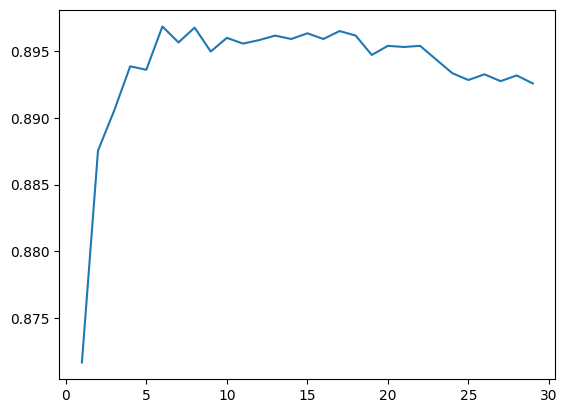

In [ ]:
plt.plot(k_list, acc_list)
# plt.xlim(3.0, 7.0)

In [ ]:
model = KNeighborsClassifier(n_neighbors = 6)
model.fit(X_train, y_train)
final_model = model.predict(X_test)

In [ ]:
df_sub['loan_status'] = final_model

In [ ]:
df_sub.to_csv('sub.csv', index=False, index_label=False)

# Loan Approval Prediction Project

## Introduction
This project aims to predict loan approval status (`loan_status`) based on various personal and loan-related features. The solution involves data loading, preprocessing, exploratory data analysis (implicitly done through `value_counts` and `info`), and building a K-Nearest Neighbors (KNN) classification model.

## Dataset Description
The dataset consists of two main files: `train.csv` for training and `test.csv` for prediction. The training dataset `df_train` has 58,645 entries and 13 columns, while the test dataset `df_test` has 39,098 entries and 12 columns. The `loan_status` column is the target variable in the training set.

**Key Features:**
*   `id`: Unique identifier (dropped during preprocessing).
*   `person_age`: Age of the person.
*   `person_income`: Annual income of the person.
*   `person_home_ownership`: Type of home ownership (e.g., RENT, MORTGAGE, OWN, OTHER).
*   `person_emp_length`: Employment length in years.
*   `loan_intent`: Purpose of the loan (e.g., EDUCATION, MEDICAL, PERSONAL).
*   `loan_grade`: Loan grade assigned by the lender.
*   `loan_amnt`: Loan amount.
*   `loan_int_rate`: Interest rate of the loan.
*   `loan_percent_income`: Loan amount as a percentage of income.
*   `cb_person_default_on_file`: Credit history indicating default.
*   `cb_person_cred_hist_length`: Credit history length in years.
*   `loan_status`: Target variable (0 for approved, 1 for rejected).

## Data Preprocessing
The following steps were performed to prepare the data:
1.  **Dropped 'id' column**: The 'id' column was removed from both training and test datasets as it's not a predictive feature.
2.  **Handling Missing Values**: No missing values were found in either the training or test datasets.
3.  **Label Encoding Categorical Features**: The following categorical columns were converted into numerical representations using `LabelEncoder`:
    *   `person_home_ownership`
    *   `loan_intent`
    *   `loan_grade`
    *   `cb_person_default_on_file`

## Model Training and Evaluation
1.  **Data Splitting**: The training data (`df_train`) was split into training and validation sets (`X_train`, `X_val`, `y_train`, `y_val`) with a `test_size` of 0.2 and `random_state` of 42.
2.  **Model Selection**: A K-Nearest Neighbors (KNN) classifier was chosen for this task.
3.  **Hyperparameter Tuning (K-value)**: An iterative process was used to find the optimal `k` for the KNN model by testing `k` values from 1 to 29 and evaluating `accuracy_score` on the validation set. The plot generated suggests that a `k` value of 6 yielded a good accuracy.
4.  **Final Model Training**: The KNN model was trained with `n_neighbors = 6` on the full training data (`X_train`, `y_train`).
5.  **Prediction**: The trained model was used to predict `loan_status` on the `X_test` dataset.

## Submission
The predictions were saved to a CSV file named `sub.csv` with 'id' and 'loan_status' columns, suitable for submission.